# ACT Regression (From-Scratch NN)

## Step 1: Load Data
This notebook loads the EdGap dataset from the original URL and reproduces the preprocessing logic before we build a NumPy-based neural network.


In [1]:
import pandas as pd
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings("ignore", category=UserWarning, message="Unknown extension is not supported and will be removed")

sns.set_style("whitegrid")

df = pd.read_excel(
    "https://raw.githubusercontent.com/brian-fischer/DATA-5100/main/EdGap_data.xlsx",
    dtype={"NCESSCH School ID": object},
)
df.head()


,NCESSCH School ID,CT Unemployment Rate,CT Pct Adults with College Degree,CT Pct Childre In Married Couple Family,CT Median Household Income,School ACT average (or equivalent if SAT score),School Pct Free and Reduced Lunch
0,100001600143,0.117962,0.445283,0.346495,42820.0,20.433455,0.066901
1,100008000024,0.063984,0.662765,0.767619,89320.0,19.498168,0.112412
2,100008000225,0.056460,0.701864,0.713090,84140.0,19.554335,0.096816
3,100017000029,0.044739,0.692062,0.641283,56500.0,17.737485,0.296960
4,100018000040,0.077014,0.640060,0.834402,54015.0,18.245421,0.262641


## Step 2: Rename, Clean, and Impute
Rename columns to match the notebook, mark invalid values as missing, and fill missing predictors with their mode. Outputs number of missing values in each column as a check.


In [2]:
df = df.rename(columns={
    "NCESSCH School ID": "id",
    "CT Pct Adults with College Degree": "percent_college",
    "CT Unemployment Rate": "rate_unemployment",
    "CT Pct Childre In Married Couple Family": "percent_married",
    "CT Median Household Income": "median_income",
    "School ACT average (or equivalent if SAT score)": "average_act",
    "School Pct Free and Reduced Lunch": "percent_lunch",
})

df.loc[df["average_act"] < 1, "average_act"] = np.nan
df.loc[df["percent_lunch"] < 0, "percent_lunch"] = np.nan

input_modes = df[df.columns.difference(["id", "average_act"])].mode().iloc[0]
df = df.fillna(input_modes)
df = df.dropna()
df.isna().sum()


id                   0
rate_unemployment    0
percent_college      0
percent_married      0
median_income        0
average_act          0
percent_lunch        0
dtype: int64

## Step 3: Split and Standardize
Split into train/test and use `StandardScaler` to put features on the same scale (mean 0, std 1). This helps neural nets train more reliably.


In [3]:
X = df[df.columns.difference(["id", "average_act"]) ]
y = df["average_act"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

## Step 4: From-Scratch NN (JAX) — Hyperparameters
Define the model size and training settings before building the network.


In [4]:
# Hyperparameters
input_dim = X_train.shape[1]
hidden_dim = 100
output_dim = 1
lr = 1e-3
epochs = 8000


### Step 4.1: Initialize Weights and Biases
We start with small random weights and zero biases for the neurons to break symmetry and keep early activations stable. Each neuron produces learned feature, and all of those will feed into the final output to compute score.


In [5]:
# Initialize flexible network parameters (JAX)
# Example architecture: input -> 64 -> 32 -> 1
layer_sizes = [input_dim, 64, 32, 1]


def init_network_params(layer_sizes, seed=2999):
    """Initialize one weight matrix and one bias vector per layer."""
    key = jax.random.PRNGKey(seed)
    params = []

    for idx in range(len(layer_sizes) - 1):
        key, subkey = jax.random.split(key)
        W = jax.random.normal(subkey, (layer_sizes[idx], layer_sizes[idx + 1])) * 0.01
        b = jnp.zeros((1, layer_sizes[idx + 1]))
        params.append({"W": W, "b": b})

    return params


params = init_network_params(layer_sizes, seed=2999)

# Checkpoint: print initialized shapes
for i, layer in enumerate(params):
    print(f"Layer {i + 1}: W {layer['W'].shape}, b {layer['b'].shape}")


Layer 1: W (5, 64), b (1, 64)
Layer 2: W (64, 32), b (1, 32)
Layer 3: W (32, 1), b (1, 1)


### Step 4.2: Activation Functions
Define ReLU and its gradient for the hidden layer.


In [6]:
def relu(x):
    return jnp.maximum(0, x)

def relu_grad(x):
    return (x > 0).astype(float)


### Step 4.3: Prepare Data for JAX and Define Forward/Loss
Convert arrays to `jnp` and define the forward pass plus MSE loss. Forward takes inputs and produces predictions using current weights. MSE loss measures how wrong the predictions are compared to true values. Returns single number that we try to minimize during training.


In [7]:
# Convert data to JAX arrays
X_train_j = jnp.array(X_train)
X_test_j = jnp.array(X_test)
y_train_j = jnp.array(y_train.to_numpy()).reshape(-1, 1)
y_test_j = jnp.array(y_test.to_numpy()).reshape(-1, 1)

def forward(params, X):
    """Flexible forward pass for an arbitrary depth MLP.

    Hidden layers use ReLU and the final layer is linear (regression).
    """
    activations = X
    num_layers = len(params)

    for layer_idx, layer in enumerate(params):
        W = layer["W"]
        b = layer["b"]
        z = activations @ W + b

        if layer_idx < num_layers - 1:
            activations = relu(z)
        else:
            activations = z

    return activations

def mse_loss(params, X, y):
    y_pred = forward(params, X)
    return jnp.mean((y_pred - y) ** 2)

# Set up parameters and gradient function using loss
grad_fn = jax.jit(jax.grad(mse_loss))


### Step 4.4: Training Loop (JAX)
Use gradients to update parameters each epoch. Check each test data point's predicted vs real at each iteration. Update neurons and parameters.


In [8]:
# Reusable SGD update helper

def sgd_update(params, grads, lr):
    """Apply vanilla SGD to the list-of-dict parameter structure."""
    return [
        {
            "W": layer["W"] - lr * grad["W"],
            "b": layer["b"] - lr * grad["b"],
        }
        for layer, grad in zip(params, grads)
    ]


# Full-batch training loop
loss_history = np.zeros(epochs, dtype=float)

for epoch in range(epochs):
    grads = grad_fn(params, X_train_j, y_train_j)
    params = sgd_update(params, grads, lr)
    loss_history[epoch] = float(mse_loss(params, X_train_j, y_train_j))

# Backwards compatibility with older references in notebook
losses = loss_history

final_loss = loss_history[-1]
print(f"Training complete after {epochs} epochs. Final train loss: {final_loss:.4f}")


Training complete after 8000 epochs. Final train loss: 2.2637


### Step 4.5: Evaluate and Plot
After model is trained and parameters are adjusted, use the remaining 20% test data to test the network on the test set, compute test MSE, and plot predicted vs actual. 


Test MSE: 2.3268959522247314


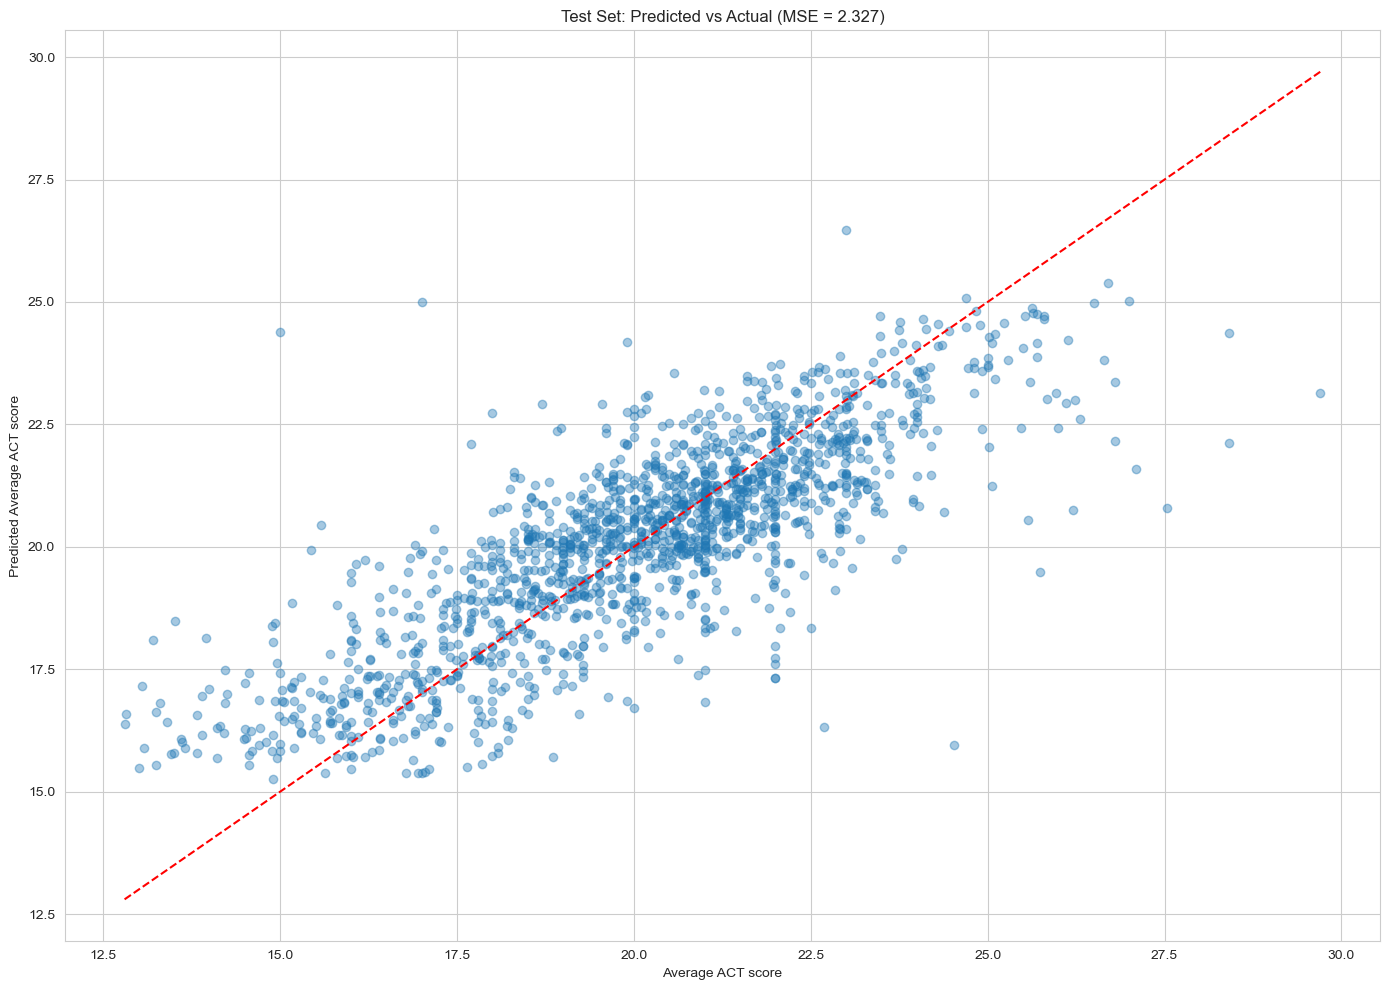

In [9]:
# Test predictions
y_test_pred = forward(params, X_test_j)

y_true = np.array(y_test_j).flatten()
y_pred = np.array(y_test_pred).flatten()

mse = mean_squared_error(np.array(y_test_j), np.array(y_test_pred))
print("Test MSE:", mse)

fig = plt.figure(figsize=(14,10))

ax = fig.add_subplot()

# Bottom: Predicted vs Actual scatter with y=x
ax.plot(y_true, y_pred, "o", alpha=0.4)
min_val = min(y_true.min(), y_pred.min())
max_val = max(y_true.max(), y_pred.max())
ax.plot([min_val, max_val], [min_val, max_val], "r--")
ax.set_xlabel("Average ACT score")
ax.set_ylabel("Predicted Average ACT score")
ax.set_title(f"Test Set: Predicted vs Actual (MSE = {mse:.3f})")

plt.tight_layout()


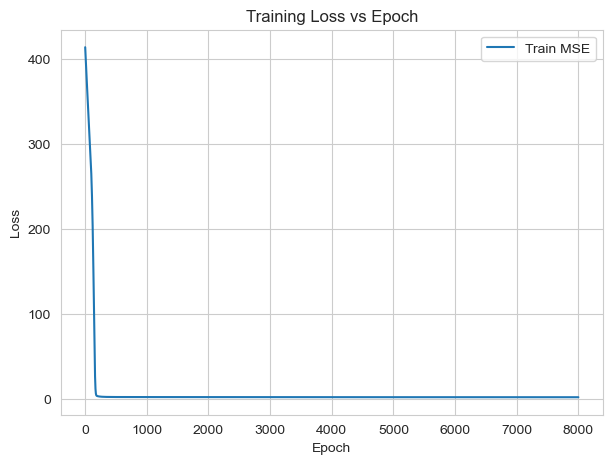

In [ ]:
fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot()

ax.plot(np.arange(epochs), losses, label="Train MSE")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training Loss vs Epoch")
ax.legend()
ax.grid(True)